Starting Burn in


/Users/clarissardoo/Projects/orbitize/orbitize/priors.py:416: RuntimeWarning: invalid value encountered in log
  lnprob = -np.log((element_array * normalizer))
/Users/clarissardoo/Projects/orbitize/orbitize/priors.py:416: RuntimeWarning: invalid value encountered in log
  lnprob = -np.log((element_array * normalizer))
/Users/clarissardoo/Projects/orbitize/orbitize/priors.py:564: RuntimeWarning: invalid value encountered in log
  lnprob = np.log(np.sin(element_array) / normalization)
/Users/clarissardoo/Projects/orbitize/orbitize/priors.py:416: RuntimeWarning: invalid value encountered in log
  lnprob = -np.log((element_array * normalizer))
/Users/clarissardoo/Projects/orbitize/orbitize/priors.py:416: RuntimeWarning: invalid value encountered in log
  lnprob = -np.log((element_array * normalizer))
/Users/clarissardoo/Projects/orbitize/orbitize/priors.py:416: RuntimeWarning: invalid value encountered in log
  lnprob = -np.log((element_array * normalizer))
/Users/clarissardoo/Projects/orb

1000/1000 steps of burn-in complete
Burn in complete. Sampling posterior now.
5000/5000 steps completed
Run complete

  target_1: high SNR orbit close to 2000d — RESULTS
          sma1: 3.2953  (+0.3422 / -0.2500)
          ecc1: 0.5117  (+0.1028 / -0.1012)
          inc1: 1.2663  (+0.0468 / -0.0502)
          aop1: 3.2125  (+0.1889 / -0.1739)
          pan1: 3.6516  (+0.0409 / -0.0393)
          tau1: 0.6855  (+0.0373 / -0.0319)
           plx: 16.1259  (+0.0099 / -0.0100)
            m1: 0.0073  (+0.0006 / -0.0006)
            m0: 1.0004  (+0.0983 / -0.1008)
    dr4_ra_off: 0.0254  (+0.0277 / -0.0252)
   dr4_dec_off: 0.0763  (+0.0438 / -0.0432)
      dr4_pmra: 5.4140  (+0.0119 / -0.0134)
     dr4_pmdec: -24.1237  (+0.0087 / -0.0102)

  Companion mass: 7.69 M_Jup


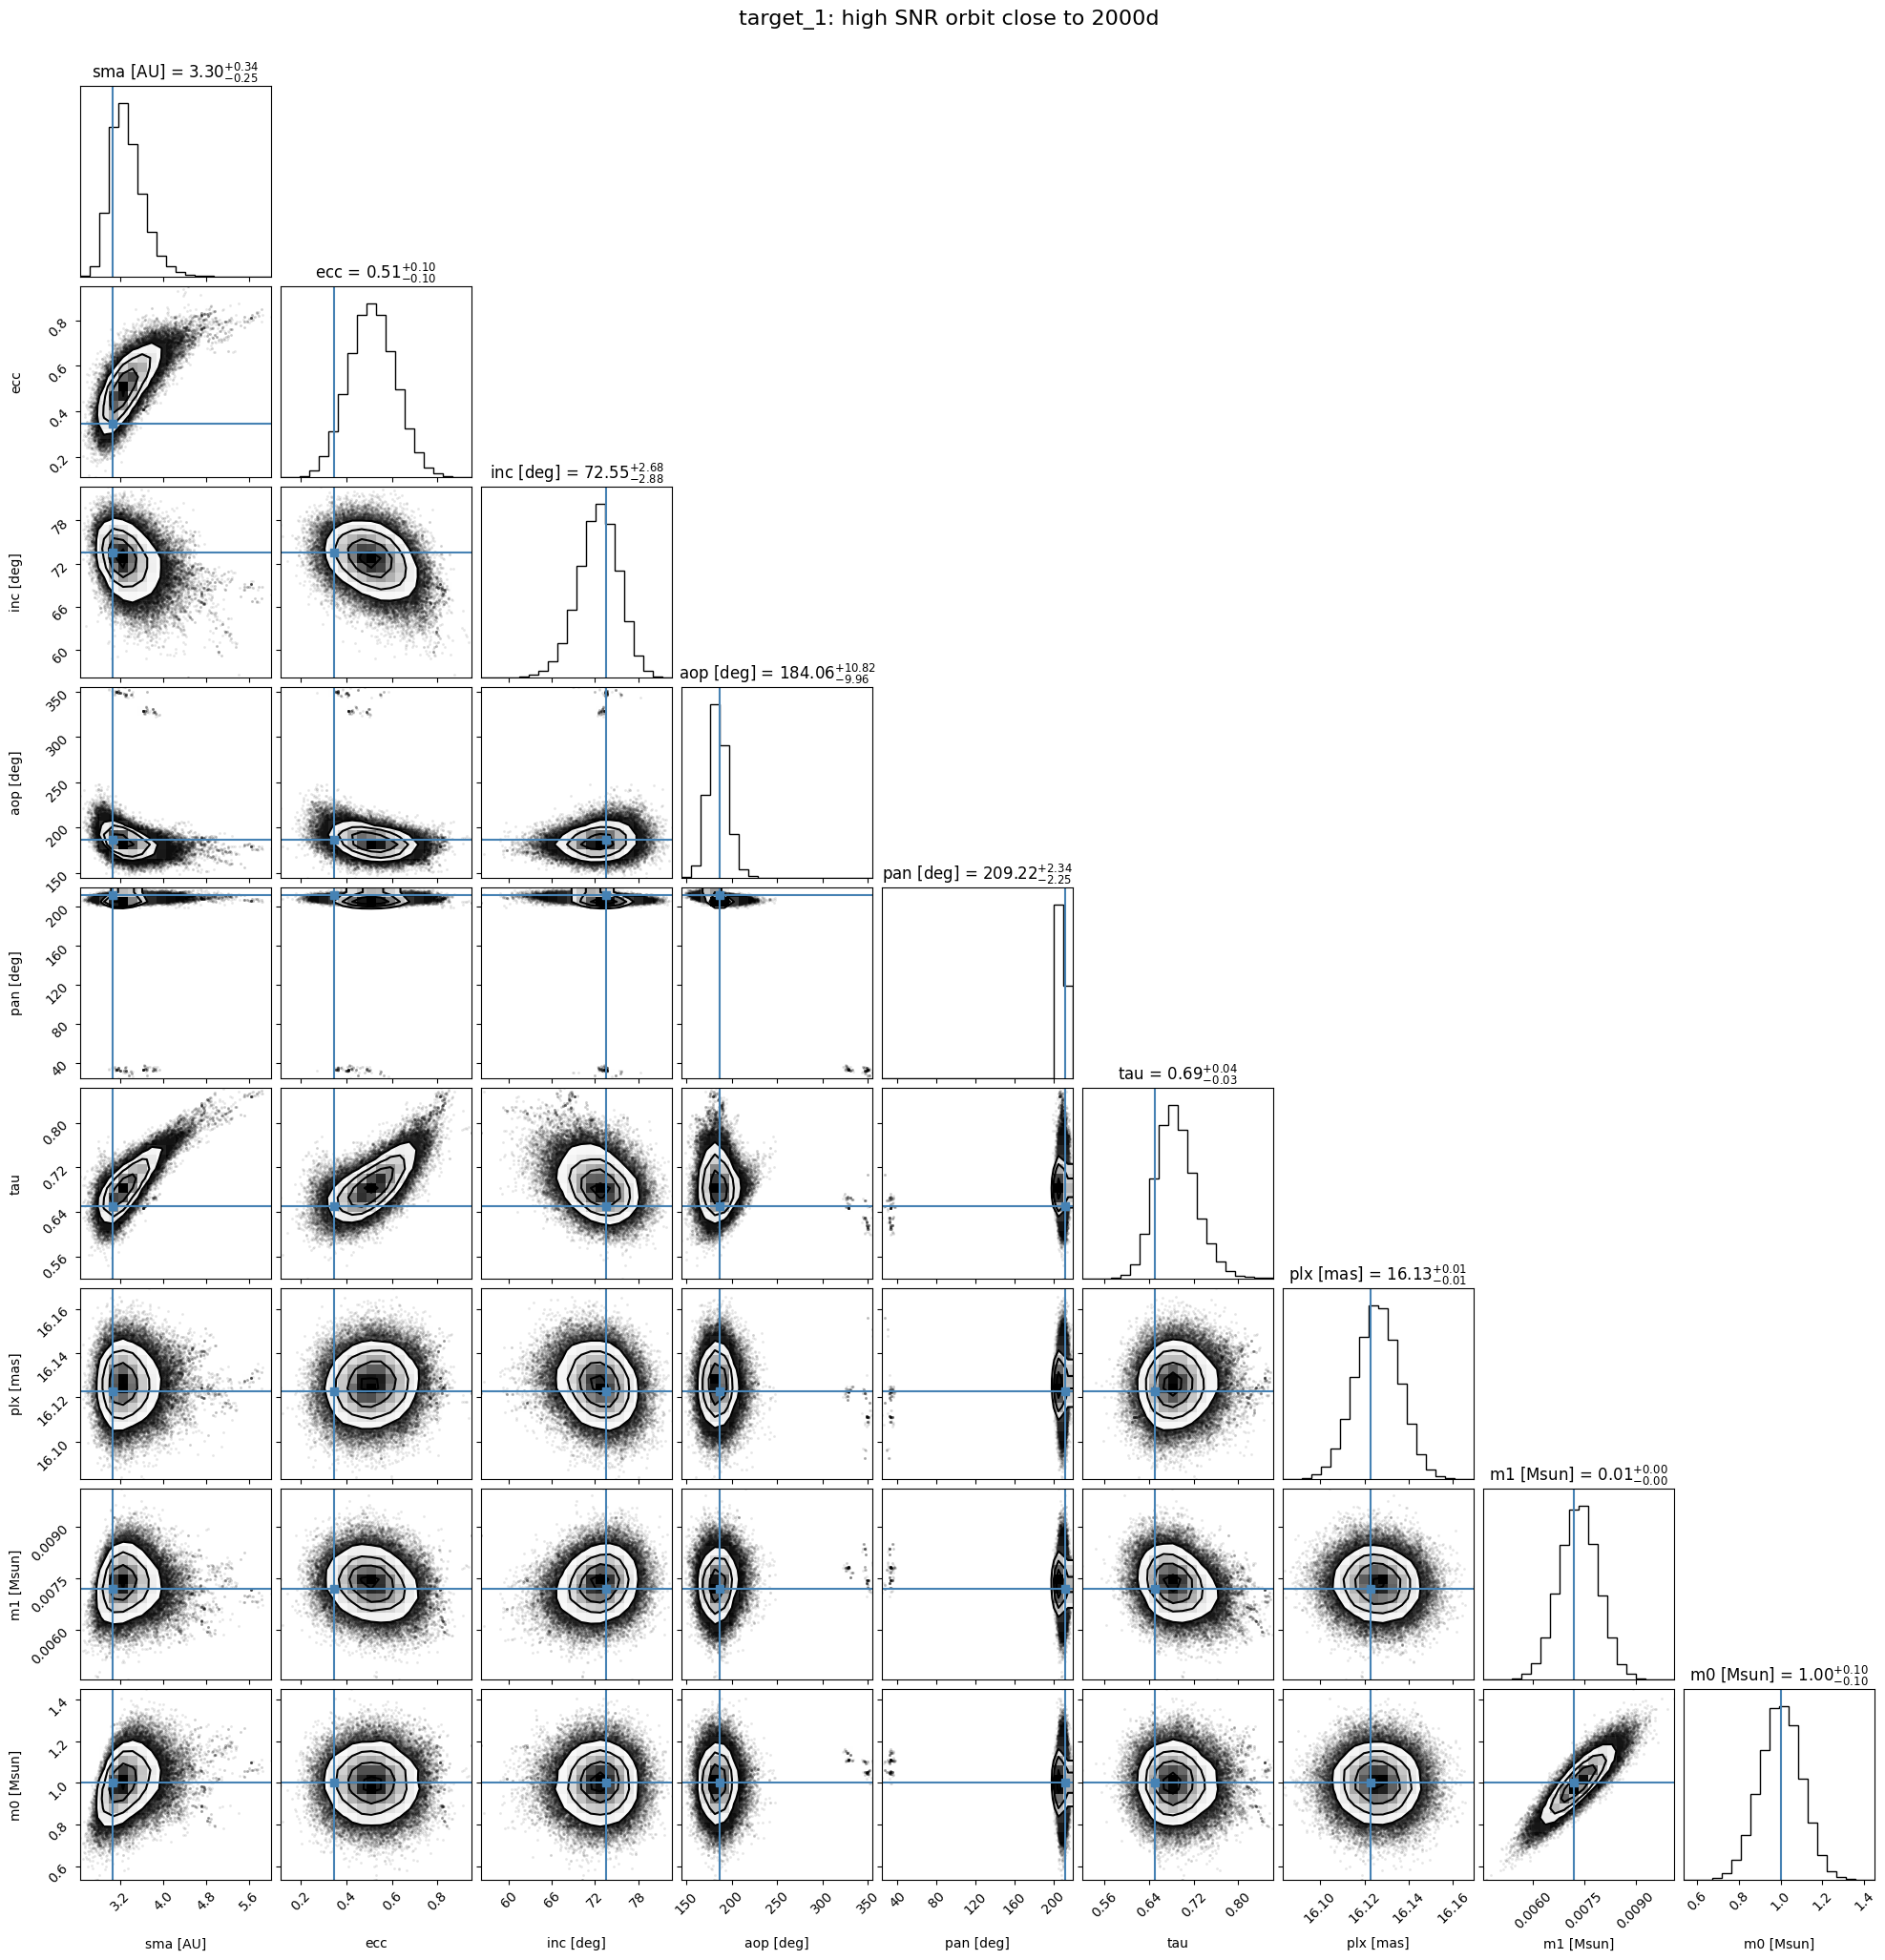

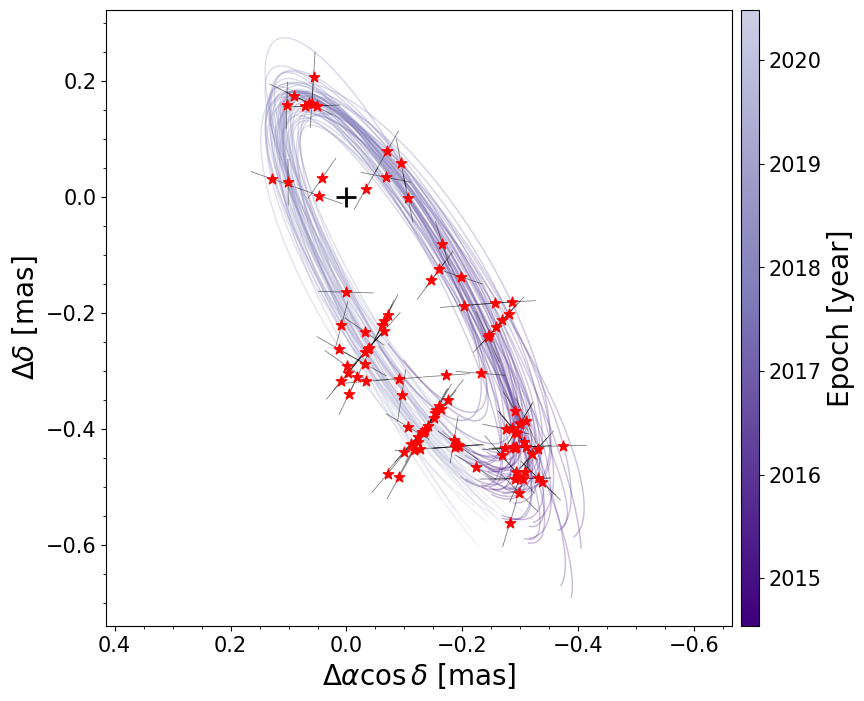

In [5]:
import pandas as pd
import numpy as np, os, corner, matplotlib.pyplot as plt
from astropy import table as astropy_table
from orbitize import system as osys, priors, sampler, gaia


# read solutions to pull pmra, pmdec, ra, dec that will be provided in the catalog.
# we also want to overplot true orbit to check that it matches our result
solutions = pd.read_csv(os.path.join("../orbitize/example_data","injected_solutions.csv"))
target_file = "target_1.csv"
row = solutions[solutions["filename"] == target_file].iloc[0]
target_name = f"{target_file.replace('.csv','')}: {row['comment']}"
dr4_filepath = os.path.join("../orbitize/example_data",target_file)
catalog_pmra = row["mu_alpha_mas_yr"]
catalog_pmra_err = 0.02
catalog_pmdec = row["mu_delta_mas_yr"]
catalog_pmdec_err = 0.02
plx_guess = row["parallax_mas"]
plx_err = 0.5

# Truth dict
if not np.isnan(row["P_d"]):
    P_yr = row["P_d"] / 365.25
    m_b = row["m_b"] / 1047.57
    sma = (P_yr**2 * (1.0 + m_b))**(1./3.)
    truth = dict(
        sma=sma, ecc=row["e"], inc_deg=row["i_deg"],
        omega_star_deg=row["omega_deg"], Omega_star_deg=row["big_omega_deg"],
        M0_deg=row["M0_deg"], P_d=row["P_d"],
        plx=row["parallax_mas"], m_b_mjup=row["m_b"], m0=1.0,
    )
else:
    truth = None


# set up prior ranges, sampler params, ref epochs
m0_guess, m0_err = 1.0, 0.1
m1_lo, m1_hi = 1e-4, 0.1
sma_lo, sma_hi = 0.05, 50.0
ecc_lo, ecc_hi = 0.01, 0.99
num_walkers, num_temps, num_threads = 100, 10, 10
total_steps, burn_steps, thin = 5000, 1000, 5
GAIA_REF_MJD = 2457936.875-2400000.5
TAU_REF_EPOCH = 58849

dr4 = gaia.DR4LogProb(
    gaia_num=0, dr4_filepath=dr4_filepath,
    catalog_pmra=catalog_pmra, catalog_pmra_err=catalog_pmra_err,
    catalog_pmdec=catalog_pmdec, catalog_pmdec_err=catalog_pmdec_err,
)

# dummy relative astrometry so orbitize doesn't break, note giant errors
data_table = astropy_table.Table(
    [[57000.0], [1], [100.0], [1e6], [0.0], [1e6],
     ["seppa"], [np.nan], ["dummy"]],
    names=("epoch", "object", "quant1", "quant1_err",
           "quant2", "quant2_err", "quant_type", "quant12_corr", "instrument"),
)

my_sys = osys.System(
    num_secondary_bodies=1, data_table=data_table,
    stellar_or_system_mass=m0_guess, plx=plx_guess,
    mass_err=m0_err, plx_err=plx_err,
    fit_secondary_mass=True, gaia=dr4, tau_ref_epoch=TAU_REF_EPOCH,
)

#set up prior pdf in system
pi = my_sys.param_idx
my_sys.sys_priors[pi["sma1"]] = priors.LogUniformPrior(sma_lo, sma_hi)
my_sys.sys_priors[pi["ecc1"]] = priors.UniformPrior(ecc_lo, ecc_hi)
my_sys.sys_priors[pi["inc1"]] = priors.SinPrior()
my_sys.sys_priors[pi["aop1"]] = priors.UniformPrior(0, 2*np.pi)
my_sys.sys_priors[pi["pan1"]] = priors.UniformPrior(0, 2*np.pi)
my_sys.sys_priors[pi["tau1"]] = priors.UniformPrior(0., 1.)
my_sys.sys_priors[pi["plx"]] = priors.GaussianPrior(plx_guess, plx_err)
my_sys.sys_priors[pi["m0"]] = priors.GaussianPrior(m0_guess, m0_err)
my_sys.sys_priors[pi["m1"]] = priors.LogUniformPrior(m1_lo, m1_hi)

#run mcmc sampler
mcmc = sampler.MCMC(my_sys, num_temps=num_temps,
                     num_walkers=num_walkers, num_threads=num_threads)
mcmc.run_sampler(num_walkers * total_steps, burn_steps=burn_steps, thin=thin)

results = mcmc.results
post = results.post

# Summary
print(f"\n{'='*60}\n  {target_name} — RESULTS\n{'='*60}")
for i, label in enumerate(my_sys.labels):
    med = np.median(post[:, i])
    lo, hi = np.percentile(post[:, i], [16, 84])
    print(f"  {label:>12s}: {med:.4f}  (+{hi-med:.4f} / -{med-lo:.4f})")

m1_jup = post[:, pi["m1"]]*1047.57
print(f"\n  Companion mass: {np.median(m1_jup):.2f} M_Jup")


# Corner plot with truth overplotted as blue lines
labels = ["sma1", "ecc1", "inc1", "aop1", "pan1", "tau1", "plx", "m1", "m0"]
idx = [pi[l] for l in labels]

plot_post = post[:, idx].copy()
plot_post[:, 2] = np.degrees(plot_post[:, 2])
plot_post[:, 3] = np.degrees(plot_post[:, 3])
plot_post[:, 4] = np.degrees(plot_post[:, 4])

tau_true = (-truth["M0_deg"] / 360.0 + (GAIA_REF_MJD - TAU_REF_EPOCH) / truth["P_d"]) % 1

truth_vals = [
    truth["sma"],
    truth["ecc"],
    truth["inc_deg"],
    (truth["omega_star_deg"] + 180)%360,
    (truth["Omega_star_deg"] + 180)%360,
    tau_true,
    truth["plx"],
    truth["m_b_mjup"] / 1047.57,
    truth["m0"],
]

labels_deg = ["sma [AU]", "ecc", "inc [deg]", "aop [deg]", "pan [deg]",
              "tau", "plx [mas]", "m1 [Msun]", "m0 [Msun]"]

fig = corner.corner(plot_post, labels=labels_deg, truths=truth_vals, show_titles=True)
fig.suptitle(target_name, fontsize=16, y=1.02)
plt.show()


# Orbit plot
fig2 = results.plot_dr4_orbit(my_sys, num_orbits_to_plot=50)
plt.show()